# Original vs Type 1 vs Type 2 Comparison

This notebook loads trained generators from the four *_new folders and draws side-by-side sample comparisons for Original, Type 1, and Type 2.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from typing import Optional

from einops import rearrange

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Generator architecture copied from train_and_test notebooks/scripts
class MultiHeadAttention(nn.Module):
    def __init__(self, emb_size, num_heads, dropout):
        super().__init__()
        self.emb_size = emb_size
        self.num_heads = num_heads
        self.keys = nn.Linear(emb_size, emb_size)
        self.queries = nn.Linear(emb_size, emb_size)
        self.values = nn.Linear(emb_size, emb_size)
        self.att_drop = nn.Dropout(dropout)
        self.projection = nn.Linear(emb_size, emb_size)

    def forward(self, x: Tensor, mask: Optional[Tensor] = None) -> Tensor:
        queries = rearrange(self.queries(x), "b n (h d) -> b h n d", h=self.num_heads)
        keys = rearrange(self.keys(x), "b n (h d) -> b h n d", h=self.num_heads)
        values = rearrange(self.values(x), "b n (h d) -> b h n d", h=self.num_heads)
        energy = torch.einsum("bhqd, bhkd -> bhqk", queries, keys)
        if mask is not None:
            fill_value = torch.finfo(torch.float32).min
            energy = energy.masked_fill(~mask, fill_value)
        scaling = self.emb_size ** (1 / 2)
        att = F.softmax(energy / scaling, dim=-1)
        att = self.att_drop(att)
        out = torch.einsum("bhal, bhlv -> bhav", att, values)
        out = rearrange(out, "b h n d -> b n (h d)")
        out = self.projection(out)
        return out


class ResidualAdd(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, **kwargs):
        res = x
        x = self.fn(x, **kwargs)
        x += res
        return x


class FeedForwardBlock(nn.Sequential):
    def __init__(self, emb_size, expansion, drop_p):
        super().__init__(
            nn.Linear(emb_size, expansion * emb_size),
            nn.GELU(),
            nn.Dropout(drop_p),
            nn.Linear(expansion * emb_size, emb_size),
        )


class Gen_TransformerEncoderBlock(nn.Sequential):
    def __init__(self, emb_size, num_heads=5, drop_p=0.5, forward_expansion=4, forward_drop_p=0.5):
        super().__init__(
            ResidualAdd(nn.Sequential(
                nn.LayerNorm(emb_size),
                MultiHeadAttention(emb_size, num_heads, drop_p),
                nn.Dropout(drop_p),
            )),
            ResidualAdd(nn.Sequential(
                nn.LayerNorm(emb_size),
                FeedForwardBlock(emb_size, expansion=forward_expansion, drop_p=forward_drop_p),
                nn.Dropout(drop_p),
            )),
        )


class Gen_TransformerEncoder(nn.Sequential):
    def __init__(self, depth=8, **kwargs):
        super().__init__(*[Gen_TransformerEncoderBlock(**kwargs) for _ in range(depth)])


class Generator(nn.Module):
    def __init__(
        self,
        seq_len=150,
        patch_size=15,
        channels=3,
        latent_dim=100,
        embed_dim=10,
        depth=3,
        forward_drop_rate=0.5,
        attn_drop_rate=0.5,
    ):
        super().__init__()
        self.channels = channels
        self.latent_dim = latent_dim
        self.seq_len = seq_len
        self.embed_dim = embed_dim
        self.patch_size = patch_size
        self.depth = depth
        self.attn_drop_rate = attn_drop_rate
        self.forward_drop_rate = forward_drop_rate

        self.l1 = nn.Linear(self.latent_dim, self.seq_len * self.embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.seq_len, self.embed_dim))
        self.blocks = Gen_TransformerEncoder(
            depth=self.depth,
            emb_size=self.embed_dim,
            drop_p=self.attn_drop_rate,
            forward_drop_p=self.forward_drop_rate,
        )
        self.deconv = nn.Sequential(nn.Conv2d(self.embed_dim, self.channels, 1, 1, 0))

    def forward(self, z):
        x = self.l1(z).view(-1, self.seq_len, self.embed_dim)
        x = x + self.pos_embed
        h, w = 1, self.seq_len
        x = self.blocks(x)
        x = x.reshape(x.shape[0], 1, x.shape[1], x.shape[2])
        output = self.deconv(x.permute(0, 3, 1, 2))
        output = output.view(-1, self.channels, h, w)
        return output

In [3]:
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATASET_SPECS = {
    "UCB Normal": {
        "folder": "test_ucb_new",
        "kind": "ucb",
        "csv_path": os.path.join(ROOT, "consolidated_datasets", "pcb", "ptbdb_normal.csv"),
        "seq_len": 50,
        "channels": 1,
        "patch_size": 10,
        "latent_dim": 100,
        "use_scaler": False,
    },
    "UCB Abnormal": {
        "folder": "test_ucb_abnormal_new",
        "kind": "ucb",
        "csv_path": os.path.join(ROOT, "consolidated_datasets", "pcb", "ptbdb_abnormal.csv"),
        "seq_len": 50,
        "channels": 1,
        "patch_size": 10,
        "latent_dim": 100,
        "use_scaler": False,
    },
    "UniMiB Running": {
        "folder": "test_unimib_new",
        "kind": "unimib",
        "activity": "running",
        "data_type": "adl",
        "seq_len": 150,
        "channels": 3,
        "patch_size": 30,
        "latent_dim": 100,
        "use_scaler": True,
    },
    "UniMiB Jumping": {
        "folder": "test_unimib_jumping_new",
        "kind": "unimib",
        "activity": "jumping",
        "data_type": "adl",
        "seq_len": 150,
        "channels": 3,
        "patch_size": 30,
        "latent_dim": 100,
        "use_scaler": True,
    },
}

print("Available datasets:")
for key, spec in DATASET_SPECS.items():
    print(f"- {key}: folder={spec['folder']}")

Available datasets:
- UCB Normal: folder=test_ucb_new
- UCB Abnormal: folder=test_ucb_abnormal_new
- UniMiB Running: folder=test_unimib_new
- UniMiB Jumping: folder=test_unimib_jumping_new


In [4]:
def _fit_normalizer_minus1_plus1(data_4d):
    scaler = MinMaxScaler(feature_range=(-1, 1))
    flat = data_4d.reshape(-1, data_4d.shape[-1])
    norm_flat = scaler.fit_transform(flat)
    norm_data = norm_flat.reshape(data_4d.shape)
    return norm_data, scaler


def _inverse_from_minus1_plus1(data_4d, scaler):
    flat = data_4d.reshape(-1, data_4d.shape[-1])
    inv_flat = scaler.inverse_transform(flat)
    return inv_flat.reshape(data_4d.shape)


def load_real_data(spec):
    import scipy.io

    if spec['kind'] == 'ucb':
        csv_path = spec['csv_path']
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"Missing CSV file: {csv_path}")
        df = pd.read_csv(csv_path, header=None)
        seq_len = spec['seq_len']
        data = df.iloc[:, 5:5 + seq_len].to_numpy()
        data = data[:, np.newaxis, np.newaxis, :]
        return torch.tensor(data, dtype=torch.float32), None

    if spec['kind'] == 'unimib':
        data_type = spec['data_type']
        data_root = os.path.join(ROOT, 'consolidated_datasets', 'UniMiB-SHAR', 'data')
        data_mat = os.path.join(data_root, f"{data_type}_data.mat")
        labels_mat = os.path.join(data_root, f"{data_type}_labels.mat")
        names_mat = os.path.join(data_root, f"{data_type}_names.mat")

        if not (os.path.exists(data_mat) and os.path.exists(labels_mat) and os.path.exists(names_mat)):
            raise FileNotFoundError("One or more UniMiB .mat files are missing.")

        data_dict = scipy.io.loadmat(data_mat)
        labels_dict = scipy.io.loadmat(labels_mat)
        names_dict = scipy.io.loadmat(names_mat)

        acc_data = data_dict[f"{data_type}_data"]
        labels = labels_dict[f"{data_type}_labels"]
        activity_names = names_dict[f"{data_type}_names"]

        clean_activity_names = [name[0][0] for name in activity_names]
        target_activity = spec['activity']

        if target_activity not in clean_activity_names:
            raise ValueError(f"Activity '{target_activity}' not found in UniMiB names.")

        target_label = clean_activity_names.index(target_activity) + 1
        activity_ids = labels[:, 0]
        target_indices = np.where(activity_ids == target_label)[0]

        selected = acc_data[target_indices, :]
        selected = selected.reshape(-1, 3, 1, 151)[:, :, :, :spec['seq_len']]
        norm_selected, scaler = _fit_normalizer_minus1_plus1(selected)
        return torch.tensor(norm_selected, dtype=torch.float32), scaler

    raise ValueError(f"Unsupported dataset kind: {spec['kind']}")


def build_generator(spec, checkpoint_path, device='cpu'):
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    model = Generator(
        seq_len=spec['seq_len'],
        patch_size=spec['patch_size'],
        channels=spec['channels'],
        latent_dim=spec['latent_dim'],
        depth=5,
    ).to(device)

    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model


def generate_samples(model, num_samples, latent_dim, device='cpu'):
    model.eval()
    with torch.no_grad():
        noise = torch.randn(num_samples, latent_dim, device=device)
        out = model(noise).detach().cpu().numpy()
    return out

In [5]:
def plot_4x3_dataset_type_grid(selection_cache, save_dir=None):
    import matplotlib.gridspec as gridspec

    dataset_keys = list(DATASET_SPECS.keys())
    if len(dataset_keys) != 4:
        raise ValueError(f"Expected exactly 4 datasets, got {len(dataset_keys)}: {dataset_keys}")
    if selection_cache is None:
        raise ValueError("selection_cache is required. Run plot_4x4_pca_tsne_type_grid first.")

    fig = plt.figure(figsize=(17, 12))
    outer = gridspec.GridSpec(4, 3, figure=fig, wspace=0.28, hspace=0.38)
    bottom_center_axes = [None, None, None]

    for r, dataset_key in enumerate(dataset_keys):
        spec = DATASET_SPECS[dataset_key]
        if dataset_key not in selection_cache:
            raise KeyError(f"Missing selection data for dataset: {dataset_key}")

        real_batch = selection_cache[dataset_key]['real_samples']
        fake_type1 = selection_cache[dataset_key]['type1_samples']
        fake_type2 = selection_cache[dataset_key]['type2_samples']

        num_samples_per_panel = len(real_batch)
        if num_samples_per_panel < 1:
            raise ValueError(f"No selected samples found for dataset: {dataset_key}")

        channels = spec['channels']
        seq_len = spec['seq_len']
        panel_sets = [real_batch, fake_type1, fake_type2]

        for c, panel_data in enumerate(panel_sets):
            inner = outer[r, c].subgridspec(1, num_samples_per_panel, wspace=0.35)
            panel_axes = []

            for s in range(num_samples_per_panel):
                ax = fig.add_subplot(inner[0, s])
                sample = panel_data[s]

                if channels == 1:
                    y = sample[0, 0, :seq_len]
                    ax.plot(y, linewidth=1.2, color='tab:blue')
                else:
                    names = ['X', 'Y', 'Z'] if channels == 3 else [f'Ch{k}' for k in range(channels)]
                    for ch in range(channels):
                        y = sample[ch, 0, :seq_len]
                        ax.plot(y, linewidth=1.0, alpha=0.95, label=names[ch])
                    if r == 0 and c == 2 and s == num_samples_per_panel - 1:
                        ax.legend(loc='upper right', fontsize=7, frameon=False)

                ax.grid(alpha=0.25, linewidth=0.4)
                ax.tick_params(labelsize=5, length=2)
                panel_axes.append(ax)

                if r == len(dataset_keys) - 1 and s == (num_samples_per_panel // 2):
                    bottom_center_axes[c] = ax

            if c == 0:
                panel_axes[0].set_ylabel(dataset_key, fontsize=9)

    fig.tight_layout(rect=(0.0, 0.02, 1.0, 1.0))

    # Place a), b), c) directly below the center sample in each column.
    for c, lab in enumerate(['a)', 'b)', 'c)']):
        if bottom_center_axes[c] is not None:
            pos = bottom_center_axes[c].get_position()
            x = (pos.x0 + pos.x1) / 2
            y = max(pos.y0 - 0.015, 0.005)
            fig.text(x, y, lab, ha='center', va='top', fontsize=12)

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        out_path = os.path.join(save_dir, 'all_datasets_4x3_original_type1_type2_3samples.png')
        fig.savefig(out_path, dpi=180, bbox_inches='tight')
        print(f"Saved: {out_path}")

    plt.show()

In [6]:
def plot_4x3_dataset_type_grid(selection_cache, save_dir=None):
    import matplotlib.gridspec as gridspec

    dataset_keys = list(DATASET_SPECS.keys())
    if len(dataset_keys) != 4:
        raise ValueError(f"Expected exactly 4 datasets, got {len(dataset_keys)}: {dataset_keys}")
    if selection_cache is None:
        raise ValueError("selection_cache is required. Run plot_4x4_pca_tsne_type_grid first.")

    fig = plt.figure(figsize=(17, 12))
    outer = gridspec.GridSpec(4, 3, figure=fig, wspace=0.28, hspace=0.38)
    bottom_center_axes = [None, None, None]

    for r, dataset_key in enumerate(dataset_keys):
        spec = DATASET_SPECS[dataset_key]
        if dataset_key not in selection_cache:
            raise KeyError(f"Missing selection data for dataset: {dataset_key}")

        real_batch = selection_cache[dataset_key]['real_samples']
        fake_type1 = selection_cache[dataset_key]['type1_samples']
        fake_type2 = selection_cache[dataset_key]['type2_samples']

        num_samples_per_panel = len(real_batch)
        if num_samples_per_panel < 1:
            raise ValueError(f"No selected samples found for dataset: {dataset_key}")

        channels = spec['channels']
        seq_len = spec['seq_len']
        panel_sets = [real_batch, fake_type1, fake_type2]

        for c, panel_data in enumerate(panel_sets):
            inner = outer[r, c].subgridspec(1, num_samples_per_panel, wspace=0.35)
            panel_axes = []

            for s in range(num_samples_per_panel):
                ax = fig.add_subplot(inner[0, s])
                sample = panel_data[s]

                if channels == 1:
                    y = sample[0, 0, :seq_len]
                    ax.plot(y, linewidth=1.2, color='tab:blue')
                else:
                    names = ['X', 'Y', 'Z'] if channels == 3 else [f'Ch{k}' for k in range(channels)]
                    for ch in range(channels):
                        y = sample[ch, 0, :seq_len]
                        ax.plot(y, linewidth=1.0, alpha=0.95, label=names[ch])
                    if r == 0 and c == 2 and s == num_samples_per_panel - 1:
                        ax.legend(loc='upper right', fontsize=7, frameon=False)

                ax.grid(alpha=0.25, linewidth=0.4)
                ax.tick_params(labelsize=5, length=2)
                panel_axes.append(ax)

                if r == len(dataset_keys) - 1 and s == (num_samples_per_panel // 2):
                    bottom_center_axes[c] = ax

            if c == 0:
                panel_axes[0].set_ylabel(dataset_key, fontsize=9)

    fig.tight_layout(rect=(0.0, 0.02, 1.0, 1.0))

    # Place a), b), c) directly below the center sample in each column.
    for c, lab in enumerate(['a)', 'b)', 'c)']):
        if bottom_center_axes[c] is not None:
            pos = bottom_center_axes[c].get_position()
            x = (pos.x0 + pos.x1) / 2
            y = max(pos.y0 - 0.015, 0.005)
            fig.text(x, y, lab, ha='center', va='top', fontsize=12)

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        out_path = os.path.join(save_dir, 'all_datasets_4x3_original_type1_type2_3samples.png')
        fig.savefig(out_path, dpi=180, bbox_inches='tight')
        print(f"Saved: {out_path}")

    plt.show()

In [7]:
def plot_4x3_dataset_sample_group_grid(selection_cache, save_dir=None):
    import matplotlib.gridspec as gridspec

    dataset_keys = list(DATASET_SPECS.keys())
    if len(dataset_keys) != 4:
        raise ValueError(f"Expected exactly 4 datasets, got {len(dataset_keys)}: {dataset_keys}")
    if selection_cache is None:
        raise ValueError("selection_cache is required. Run plot_4x4_pca_tsne_type_grid first.")

    first_key = dataset_keys[0]
    if first_key not in selection_cache:
        raise KeyError(f"Missing selection data for dataset: {first_key}")

    num_samples = len(selection_cache[first_key]['real_samples'])
    if num_samples < 3:
        raise ValueError(f"Need at least 3 matched samples per dataset, got {num_samples}.")

    fig = plt.figure(figsize=(17, 12))
    outer = gridspec.GridSpec(4, 3, figure=fig, wspace=0.28, hspace=0.38)
    bottom_center_axes = [None, None, None]

    method_names = ['Original', 'Type 1', 'Type 2']

    for r, dataset_key in enumerate(dataset_keys):
        spec = DATASET_SPECS[dataset_key]
        if dataset_key not in selection_cache:
            raise KeyError(f"Missing selection data for dataset: {dataset_key}")

        real_batch = selection_cache[dataset_key]['real_samples']
        fake_type1 = selection_cache[dataset_key]['type1_samples']
        fake_type2 = selection_cache[dataset_key]['type2_samples']

        channels = spec['channels']
        seq_len = spec['seq_len']

        for c in range(3):
            sample_idx = c
            inner = outer[r, c].subgridspec(1, 3, wspace=0.35)
            panel_axes = []

            method_samples = [
                real_batch[sample_idx],
                fake_type1[sample_idx],
                fake_type2[sample_idx],
            ]

            for m, sample in enumerate(method_samples):
                ax = fig.add_subplot(inner[0, m])

                if channels == 1:
                    y = sample[0, 0, :seq_len]
                    ax.plot(y, linewidth=1.2, color='tab:blue')
                else:
                    names = ['X', 'Y', 'Z'] if channels == 3 else [f'Ch{k}' for k in range(channels)]
                    for ch in range(channels):
                        y = sample[ch, 0, :seq_len]
                        ax.plot(y, linewidth=1.0, alpha=0.95, label=names[ch])
                    if r == 0 and c == 2 and m == 2:
                        ax.legend(loc='upper right', fontsize=7, frameon=False)

                if r == 0:
                    ax.set_title(method_names[m], fontsize=13)

                ax.grid(alpha=0.25, linewidth=0.4)
                ax.tick_params(labelsize=5, length=2)
                panel_axes.append(ax)

                if r == len(dataset_keys) - 1 and m == 1:
                    bottom_center_axes[c] = ax

            if c == 0:
                panel_axes[0].set_ylabel(dataset_key, fontsize=9)

    fig.tight_layout(rect=(0.0, 0.02, 1.0, 1.0))

    # Place a), b), c) below the center sub-plot of each sample column.
    for c, lab in enumerate(['a)', 'b)', 'c)']):
        if bottom_center_axes[c] is not None:
            pos = bottom_center_axes[c].get_position()
            x = (pos.x0 + pos.x1) / 2
            y = max(pos.y0 - 0.015, 0.005)
            fig.text(x, y, lab, ha='center', va='top', fontsize=12)

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        out_path = os.path.join(save_dir, 'all_datasets_4x3_by_sample_original_type1_type2.png')
        fig.savefig(out_path, dpi=180, bbox_inches='tight')
        print(f"Saved: {out_path}")

    plt.show()

In [8]:
def _to_seq_len_channels(batch_4d):
    # Convert (N, C, 1, L) -> (N, L, C) to match evaluation notebooks.
    return np.transpose(np.squeeze(batch_4d, axis=2), (0, 2, 1))


def _extract_rocket_features(fake_seq, real_seq):
    try:
        from sktime.transformations.panel.rocket import MiniRocketMultivariate
    except ImportError as exc:
        raise ImportError(
            "MiniRocket requires sktime. Install with: pip install sktime"
        ) from exc

    dist = np.concatenate((fake_seq, real_seq), axis=0)
    dist = dist.transpose(0, 2, 1)  # (N, channels, seq_len)
    rocket = MiniRocketMultivariate()
    features = rocket.fit_transform(dist)

    features_fake = features[:len(fake_seq)]
    features_real = features[len(fake_seq):]

    if hasattr(features_fake, 'to_numpy'):
        features_fake = features_fake.to_numpy()
    if hasattr(features_real, 'to_numpy'):
        features_real = features_real.to_numpy()

    return features_fake, features_real


def _compute_pca_tsne_embeddings(fake_features, real_features, random_state=43):
    combined = np.concatenate([real_features, fake_features], axis=0)

    pca_model = PCA(n_components=2)
    pca_2d = pca_model.fit_transform(combined)
    explained_var = pca_model.explained_variance_ratio_

    n_total = combined.shape[0]
    max_valid = max(2, (n_total - 1) // 3)
    perplexity = min(30, max_valid)
    tsne_2d = TSNE(
        n_components=2,
        random_state=random_state,
        init='pca',
        learning_rate='auto',
        perplexity=perplexity,
    ).fit_transform(combined)

    n_real = real_features.shape[0]
    pca_real, pca_fake = pca_2d[:n_real], pca_2d[n_real:]
    tsne_real, tsne_fake = tsne_2d[:n_real], tsne_2d[n_real:]
    return pca_real, pca_fake, tsne_real, tsne_fake, explained_var


def _select_unique_nearest_fake_indices(real_2d, fake_2d, selected_real_idx):
    if len(fake_2d) == 0:
        raise ValueError("No generated samples available for nearest-neighbor matching.")

    chosen_fake = []
    used_fake = set()

    for ridx in selected_real_idx:
        deltas = fake_2d - real_2d[ridx]
        dists = np.sqrt(np.sum(deltas * deltas, axis=1))
        sorted_fake = np.argsort(dists)

        pick = None
        for fidx in sorted_fake:
            if int(fidx) not in used_fake:
                pick = int(fidx)
                break

        if pick is None:
            pick = int(sorted_fake[0])

        chosen_fake.append(pick)
        used_fake.add(pick)

    return np.array(chosen_fake, dtype=int)


def _scatter_real_vs_fake(ax, real_2d, fake_2d, title=None, show_legend=False):
    ax.scatter(real_2d[:, 0], real_2d[:, 1], s=10, alpha=0.6, color='tab:blue', label='Original')
    ax.scatter(fake_2d[:, 0], fake_2d[:, 1], s=10, alpha=0.6, color='tab:red', label='Generated')
    if title is not None:
        ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.2, linewidth=0.4)
    ax.tick_params(labelsize=7)
    if show_legend:
        ax.legend(loc='best', fontsize=8, frameon=False)


def _format_evr_text(evr):
    return f"{evr[0] * 100:.1f}% | {evr[1] * 100:.1f}%"


def _annotate_evr_below(ax, evr, prefix="Explained var"):
    label = f"{prefix}: {_format_evr_text(evr)}"
    ax.text(
        0.5,
        -0.22,
        label,
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=13,
        clip_on=False,
    )


def plot_4x4_pca_tsne_type_grid(num_samples_per_dataset=300, save_dir=None, num_match_samples=3):
    import matplotlib.gridspec as gridspec

    dataset_keys = list(DATASET_SPECS.keys())
    if len(dataset_keys) != 4:
        raise ValueError(f"Expected exactly 4 datasets, got {len(dataset_keys)}: {dataset_keys}")

    if num_samples_per_dataset < 10:
        raise ValueError("num_samples_per_dataset must be >= 10")
    if num_match_samples < 1:
        raise ValueError("num_match_samples must be >= 1")

    fig = plt.figure(figsize=(18, 15))
    # Add one spacer row (index 2) to create visible gap between rows 2 and 3.
    gs = gridspec.GridSpec(
        5,
        4,
        figure=fig,
        height_ratios=[1.0, 1.0, 0.22, 1.0, 1.0],
        wspace=0.20,
        hspace=0.42,
    )

    row_map = [0, 1, 3, 4]
    axes = [[fig.add_subplot(gs[row_map[r], c]) for c in range(4)] for r in range(4)]
    row_labels = ['PCA', 't-SNE', 'PCA', 't-SNE']
    selection_cache = {}

    for col, dataset_key in enumerate(dataset_keys):
        spec = DATASET_SPECS[dataset_key]
        folder = os.path.join(ROOT, spec['folder'])

        type1_ckpt = os.path.join(folder, 'ckpt_tmw_type_1', 'generator_final.pth')
        type2_ckpt = os.path.join(folder, 'ckpt_tmw_type_2', 'generator_final.pth')

        real_data_model_space, scaler = load_real_data(spec)
        n_real = len(real_data_model_space)
        n_use = min(num_samples_per_dataset, n_real)

        if n_use < 10:
            raise ValueError(f"Dataset {dataset_key} has only {n_use} samples available.")
        if n_use < num_match_samples:
            raise ValueError(
                f"Dataset {dataset_key} has only {n_use} samples, cannot select {num_match_samples} matches."
            )

        real_idx = torch.randperm(n_real)[:n_use]
        real_batch_model_space = real_data_model_space[real_idx].numpy()

        gen_type1 = build_generator(spec, type1_ckpt, device=device)
        gen_type2 = build_generator(spec, type2_ckpt, device=device)
        fake_type1_model_space = generate_samples(gen_type1, n_use, spec['latent_dim'], device=device)
        fake_type2_model_space = generate_samples(gen_type2, n_use, spec['latent_dim'], device=device)

        if spec.get('use_scaler', False):
            real_batch = _inverse_from_minus1_plus1(real_batch_model_space, scaler)
            fake_type1 = _inverse_from_minus1_plus1(fake_type1_model_space, scaler)
            fake_type2 = _inverse_from_minus1_plus1(fake_type2_model_space, scaler)
        else:
            real_batch = real_batch_model_space
            fake_type1 = fake_type1_model_space
            fake_type2 = fake_type2_model_space

        real_seq = _to_seq_len_channels(real_batch)
        type1_seq = _to_seq_len_channels(fake_type1)
        type2_seq = _to_seq_len_channels(fake_type2)

        type1_feat, real_feat_1 = _extract_rocket_features(type1_seq, real_seq)
        type2_feat, real_feat_2 = _extract_rocket_features(type2_seq, real_seq)

        pca_real_1, pca_fake_1, tsne_real_1, tsne_fake_1, evr_type1 = _compute_pca_tsne_embeddings(
            type1_feat, real_feat_1, random_state=43
        )
        pca_real_2, pca_fake_2, tsne_real_2, tsne_fake_2, evr_type2 = _compute_pca_tsne_embeddings(
            type2_feat, real_feat_2, random_state=43
        )

        selected_real_idx = np.random.choice(n_use, size=num_match_samples, replace=False)
        selected_type1_idx = _select_unique_nearest_fake_indices(tsne_real_1, tsne_fake_1, selected_real_idx)
        selected_type2_idx = _select_unique_nearest_fake_indices(tsne_real_2, tsne_fake_2, selected_real_idx)

        selection_cache[dataset_key] = {
            'real_samples': real_batch[selected_real_idx],
            'type1_samples': fake_type1[selected_type1_idx],
            'type2_samples': fake_type2[selected_type2_idx],
        }

        _scatter_real_vs_fake(
            axes[0][col],
            pca_real_1,
            pca_fake_1,
            title=dataset_key,
            show_legend=(col == 3),
        )
        _scatter_real_vs_fake(axes[1][col], tsne_real_1, tsne_fake_1)
        _scatter_real_vs_fake(axes[2][col], pca_real_2, pca_fake_2)
        _scatter_real_vs_fake(axes[3][col], tsne_real_2, tsne_fake_2)

        _annotate_evr_below(axes[0][col], evr_type1, prefix="PCA var")
        _annotate_evr_below(axes[2][col], evr_type2, prefix="PCA var")

    for row in range(4):
        axes[row][0].set_ylabel(row_labels[row], fontsize=11)

    # Group labels below row 2 and row 4.
    row2_bottom = min(ax.get_position().y0 for ax in axes[1])
    row4_bottom = min(ax.get_position().y0 for ax in axes[3])
    fig.text(0.5, max(row2_bottom - 0.040, 0.02), 'TMW type 1', ha='center', va='top', fontsize=13)
    fig.text(0.5, max(row4_bottom - 0.040, 0.01), 'TMW type 2', ha='center', va='top', fontsize=13)

    # No overall title per request.
    fig.tight_layout(rect=(0.02, 0.04, 1.0, 0.99))

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        out_path = os.path.join(save_dir, 'all_datasets_4x4_pca_tsne_type1_type2.png')
        fig.savefig(out_path, dpi=180, bbox_inches='tight')
        print(f"Saved: {out_path}")

    plt.show()
    return selection_cache

C:\Users\tungv\AppData\Local\Temp\ipykernel_10956\3354988266.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.02, 0.04, 1.0, 0.99))


Saved: e:\pyenv\GTCC\KPG-RL\Hehe\image_generate\outputs\all_datasets_4x4_pca_tsne_type1_type2.png


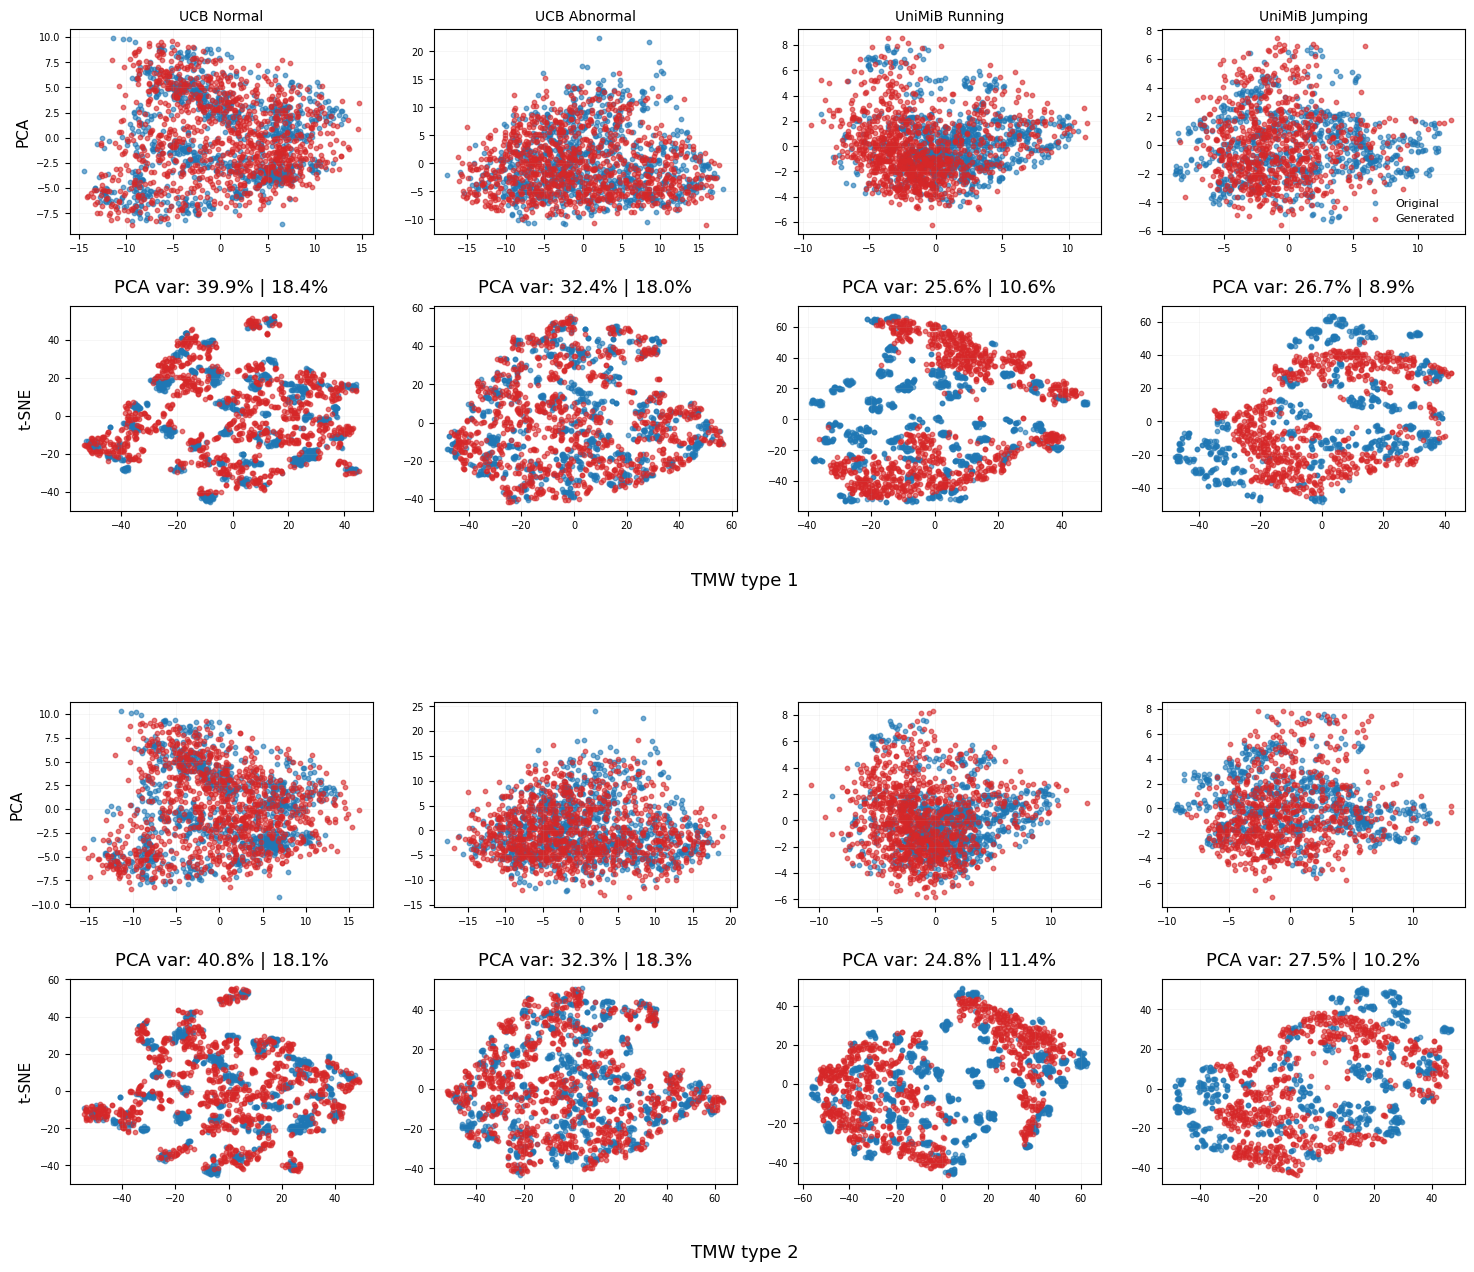

C:\Users\tungv\AppData\Local\Temp\ipykernel_10956\651777425.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.0, 0.02, 1.0, 1.0))


Saved: e:\pyenv\GTCC\KPG-RL\Hehe\image_generate\outputs\all_datasets_4x3_original_type1_type2_3samples.png


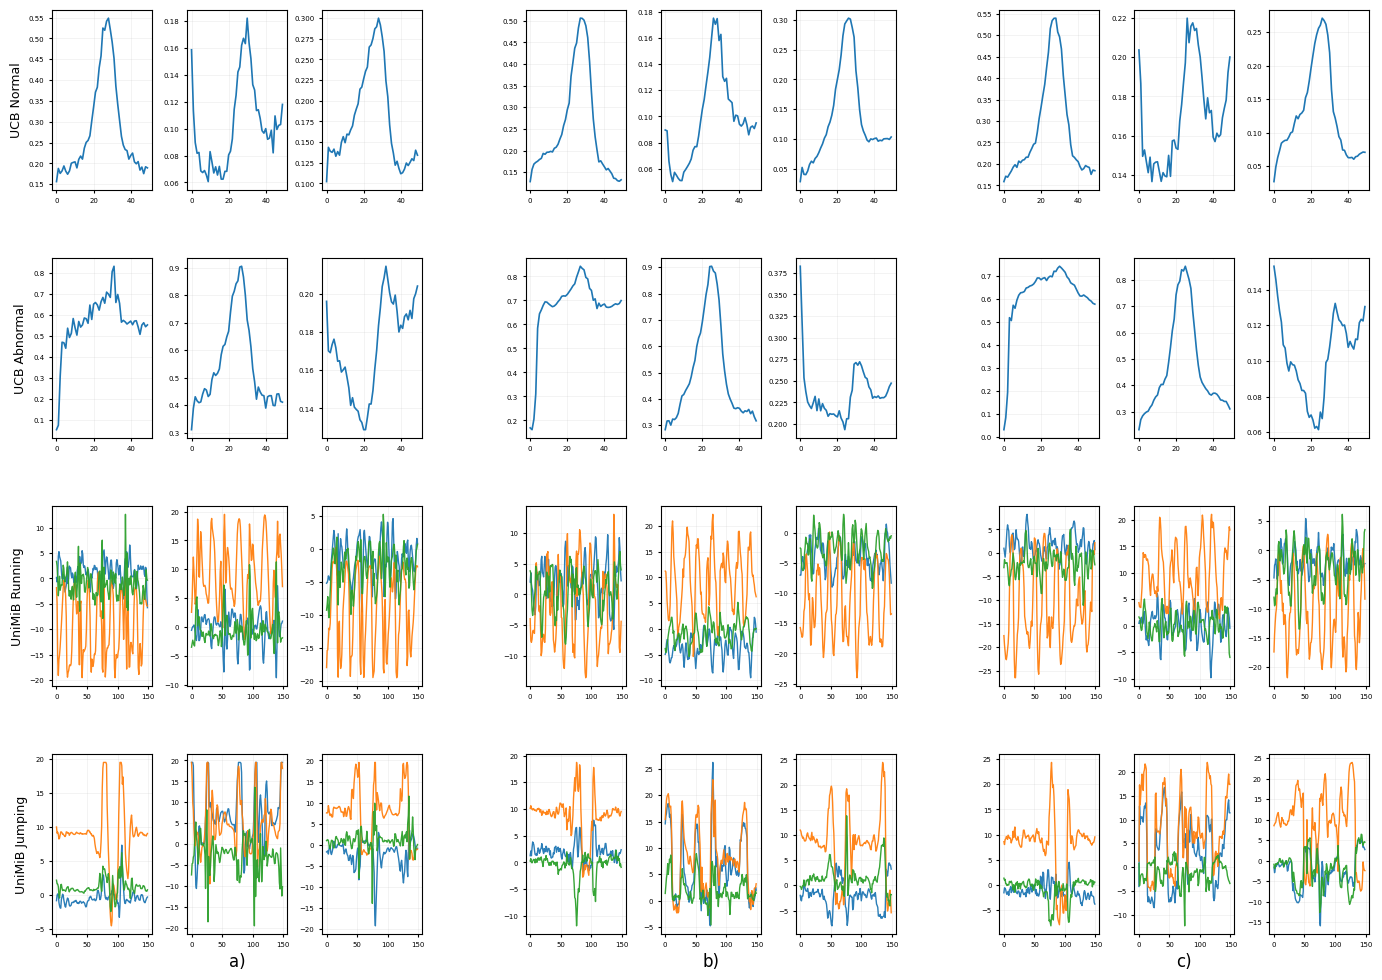

C:\Users\tungv\AppData\Local\Temp\ipykernel_10956\3170527632.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.0, 0.02, 1.0, 1.0))


Saved: e:\pyenv\GTCC\KPG-RL\Hehe\image_generate\outputs\all_datasets_4x3_by_sample_original_type1_type2.png


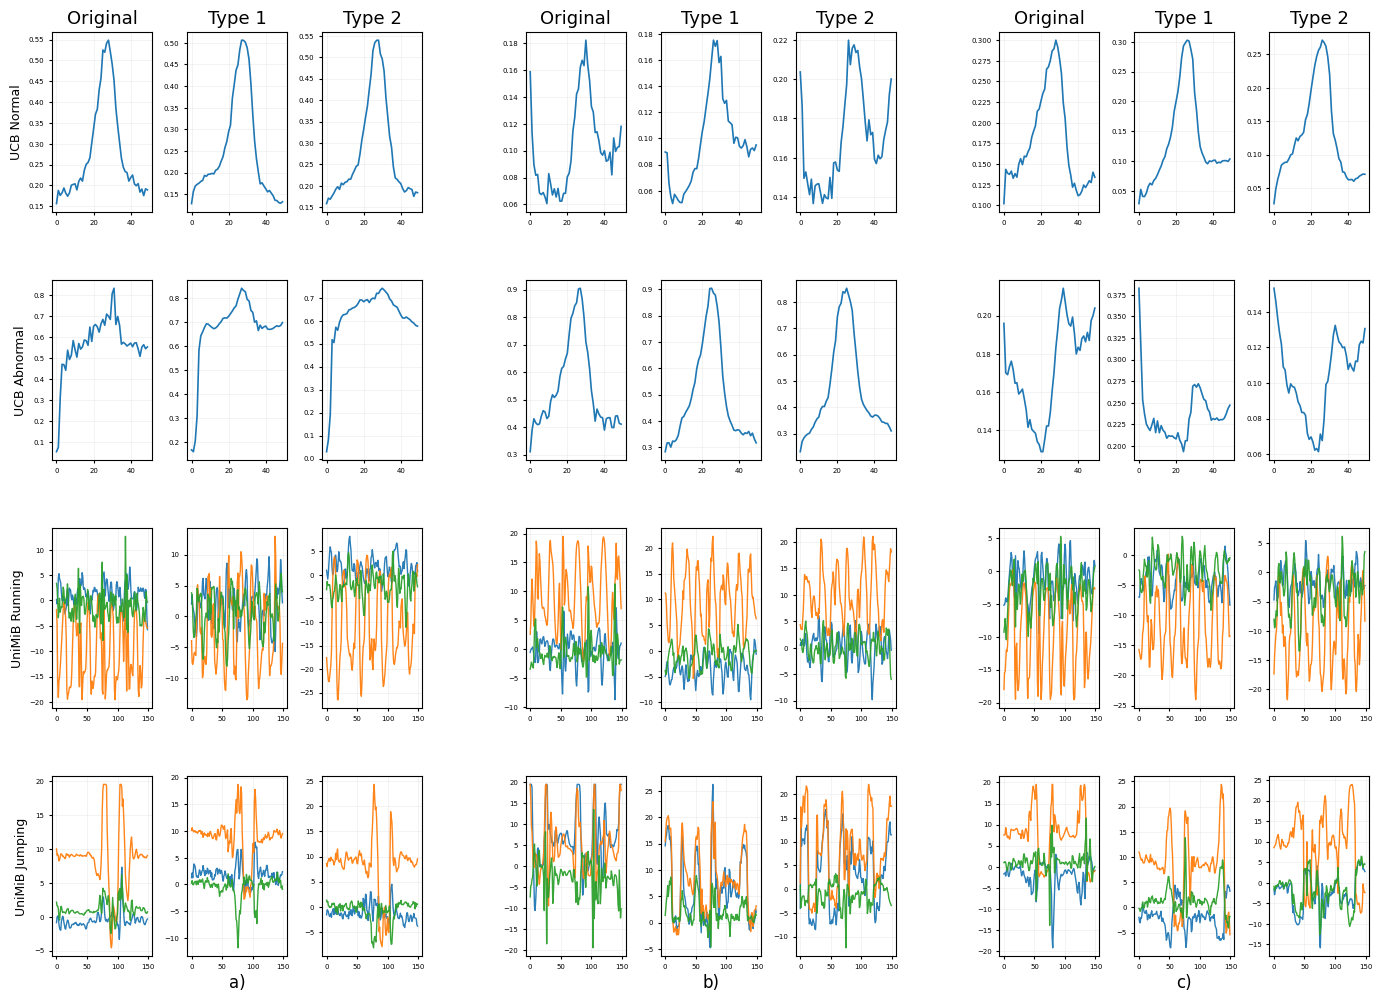

In [9]:
# First run PCA+t-SNE and cache nearest-neighbor sample matches in t-SNE space.
selection_cache = plot_4x4_pca_tsne_type_grid(
    num_samples_per_dataset=1000,
    save_dir=os.path.join(os.getcwd(), 'outputs'),
    num_match_samples=3,
 )

# Method-grouped layout: columns are Original, Type 1, Type 2.
plot_4x3_dataset_type_grid(
    selection_cache=selection_cache,
    save_dir=os.path.join(os.getcwd(), 'outputs'),
)

# Sample-grouped layout: each column is one matched sample across methods.
plot_4x3_dataset_sample_group_grid(
    selection_cache=selection_cache,
    save_dir=os.path.join(os.getcwd(), 'outputs'),
)